# Week 8：PCA 降维与可视化

目标：理解 PCA 如何在不使用标签的情况下压缩特征，并用它把 30 维数据可视化到二维。

## 1. PCA 在做什么

PCA 是 Principal Component Analysis（主成分分析）。它寻找数据变化最明显的若干方向：

- 第一个主成分：数据方差最大的方向。
- 第二个主成分：与第一个方向垂直，并在剩余方向中方差最大。
- 后续主成分：继续按同样原则寻找。

把原特征投影到前几个主成分，就能用更少维度表示大部分信息。概念上：

$$
Z = X_{\text{standardized}} W
$$

其中 `X_standardized` 是标准化后的原始特征，`W` 的列是 PCA 找到的主方向，`Z` 是降维后的新特征。

PCA 训练时不使用标签 `y`，所以它属于无监督学习；本节只在画图时用 `y` 上色，帮助我们观察结果。

## 2. 为什么先标准化

PCA 依据方差找方向。如果一个特征的数值范围天然很大，它会主导方差，即使它并不更重要。因此通常先标准化，让各特征在相近尺度上比较。

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
dataset = load_breast_cancer(as_frame=True)
X = dataset.data
y = dataset.target

print(f'原始特征数量：{X.shape[1]}')
print(f'样本数量：{X.shape[0]}')

原始特征数量：30
样本数量：569


In [3]:
# 标准化让每个特征以相近尺度参与 PCA。
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 先只保留两个主成分，便于在平面上画图。
pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_scaled)

pca_2d_result = pd.DataFrame(X_2d, columns=['PC1', 'PC2'])
pca_2d_result['target'] = y
display(pca_2d_result.head())
print('前两个主成分解释的方差比例：', pca_2d.explained_variance_ratio_)
print('前两个主成分累计解释比例：', pca_2d.explained_variance_ratio_.sum())

,PC1,PC2,target
0,9.192837,1.948583,0
1,2.387802,-3.768172,0
2,5.733896,-1.075174,0
3,7.122953,10.275589,0
4,3.935302,-1.948072,0


前两个主成分解释的方差比例： [0.44272026 0.18971182]
前两个主成分累计解释比例： 0.6324320765155944


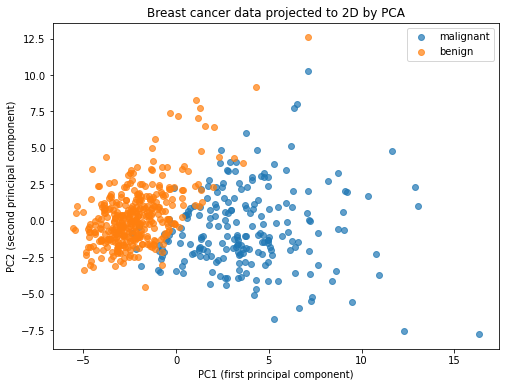

In [4]:
plt.figure(figsize=(8, 6))
for target, name in enumerate(dataset.target_names):
    mask = y == target
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1], alpha=0.7, label=name)

plt.xlabel('PC1 (first principal component)')
plt.ylabel('PC2 (second principal component)')
plt.title('Breast cancer data projected to 2D by PCA')
plt.legend()
plt.show()

In [5]:
# n_components=0.95 表示：自动保留足以解释至少 95% 方差的最少主成分数量。
pca_95 = PCA(n_components=0.95, random_state=42)
X_95 = pca_95.fit_transform(X_scaled)

print(f'保留 95% 方差后，特征数量从 {X.shape[1]} 降到 {X_95.shape[1]}')
print(f'实际累计解释比例：{pca_95.explained_variance_ratio_.sum():.3f}')

保留 95% 方差后，特征数量从 30 降到 10
实际累计解释比例：0.952


## 3. 什么时候使用 PCA

- 特征数量很多，且特征之间高度相关。
- 想降低训练、存储或可视化成本。
- 想先压缩噪声，再交给后续模型。

代价是：主成分不再像原始特征那样直观，模型可解释性可能下降。

思考题：PCA 为什么通常需要在标准化之后做？